<a href="https://colab.research.google.com/github/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/blob/main/Python%20NoteBooks/CASO_ARBOLES_DE_CLASIFICACION_RANDOM_FOREST_Y_REGRESION_LOGISTICAS_PARA_DATOS_DE_SALUD_ARBOLES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Contexto

Este caso de estudio es similar al visto con programación *R*. Se trata de implementar evaluar y comparar modelos de clasificación con información relacionada con el estado de salud de una muestra simulada de características de árboles. El caso que se presenta se construye con funcipnes de bibliotecas y funciones de *Python*.

Son 15 las variables independientes:

Las de tipo dandométricas o mediciones físicas de los árboles: *edad*, es edad estimada del árbol, unidad en años;
*altura*, es la altura total del árbol medida en metros; *diametro*, es el diámetro del tronco medido a la altura del pecho centímetros; *area*, es la superficie ocupada por la copa metros cuadrados; *densidad*, es la densidad relativa del follaje medido en porcentaje.

Variables relativas a las condiciones del suelo edáficas: *ph*, la acidez o alcalinidad del suelo; *humedad* es el  porcentaje de contenido de humedad del suelo (%); *materia_organica*, es el porcentaje de materia orgánica; *nitrogeno*, es la concentración de nitrógeno; *fosforo* es la concentración de fósforo.

Variables relativas a las condiciones del clima: *temperatura*, la temperatura promedio; *precipitacion* la cantidad de precipitación acumulada; *radiacion* el indicador de radiación solar promedio; *viento* la velocidad promedio del viento.

Variable de tipo topográfica: *altitud* que es la altitud sobre el nivel del mar.

La variable dependiente es la de *salud* que define la condición de sanidad de un árbol y puede tener valores de *Enfermedad*, *Estres_Hidrico*, *Plaga* o *Sano*.

Los datos ya vienen transformados, limpios y con clases balanceadas para garantizar certidumbre en la construcción de modelos.

Los datos para su descarga se encuentran en el enlace de github.com en el espacio del autor: https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/dataset_forestal_multinomial.csv .

Las funciones previamente codificadas y preparadas para este caso de estudio se pueden encontrar en *github.com* en PENDIENTE .

El caso de estudio se encuentra en el portal de *google collab* https://colab.research.google.com/drive/1gjJs0H3AuQDDshFi5JGvADpCBFLTPrbJ?usp=sharing .

De igual manera el caso de estudio puede encontrarse en el portal de *github.com* en https://github.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/blob/main/Python%20NoteBooks/CASO_ARBOLES_DE_CLASIFICACION_RANDOM_FOREST_Y_REGRESION_LOGISTICAS_PARA_DATOS_DE_SALUD_ARBOLES.ipynb .




# Objetivo

Crear, evaluar y comparar modelos de clasificación con datos relacionados con el estado de salud de árboles. Los modelos que se crean son árboles de clasificación, bosques aleatorios y regresión logística.

Se partición los datos *70%* para datos de entrenamiento y *30%* para datos de validación.

La evaluación de los modelos se hace a través de los estadísticos extraídos a partir de la matriz de confusión de cada modelo.

Al final se interpreta el caso de estudio mencionando el modelo con mayor calidad predictiva para estos datos.


# Descripción

Se cargan librerías, funciones que permiten la adecuada ejecución del caso de estudio; se cargan los datos, se visualizan y describen identificando los estadísticos de las variables independientes y la frecuencia de clase de la variable dependiente *salud*.

## Cargar librerías



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.preprocessing import MinMaxScaler
# from sklearn.preprocessing import PolynomialFeatures
# from sklearn.linear_model import LinearRegression
# from sklearn.linear_model import LassoCV
# from sklearn.linear_model import RidgeCV
# from sklearn.metrics import ( mean_squared_error,
#    mean_absolute_error,  r2_score )

# from scipy.stats import shapiro
# from scipy.stats import kstest
# from statsmodels.stats.diagnostic import het_breuschpagan
# from statsmodels.stats.stattools import durbin_watson
# from statsmodels.stats.outliers_influence import variance_inflation_factor
# from statsmodels.stats.diagnostic import linear_reset
# import statsmodels.api as sm

# Para validar posutalados
# from statsmodels.stats.outliers_influence import (
#    variance_inflation_factor)
# from statsmodels.stats.diagnostic import (het_breuschpagan,
#    linear_reset)
# from statsmodels.stats.stattools import ( durbin_watson)
# from scipy.stats import ( shapiro)
# from scipy.stats import shapiro
# from scipy.stats import kstest
# from scipy.stats import anderson
# from sklearn.linear_model import (  LassoCV)
# from sklearn.linear_model import (  RidgeCV)
# from sklearn.preprocessing import (PolynomialFeatures)
# from sklearn.svm import SVR # Para modelos SVR

# Para arboles de clasificación y bosques aleatorios
from sklearn.tree import DecisionTreeClassifier # Árbol de clasificación
from sklearn.ensemble import RandomForestClassifier # Bosque aleatorio de clasificación
from sklearn.tree import plot_tree # Visualización del árbol
from sklearn.tree import export_text # Exportar reglas del árbol

from sklearn.linear_model import LogisticRegression # Reg Logistica
from sklearn.utils import resample # Muestras y submuestras


## Cargar funciones


In [12]:
# Funciones para implementar y evaluar modelos de regresión logística Python
# Se crearn modelos de Regresión Logística
# Se valida el postulado de colinealidad
#
# Rubén Pizarro Gurrola
# Junio 2026

#========================================================
# CARGAR DATOS
#========================================================

def f_cargar_datos(ruta_archivo):

    datos = pd.read_csv(ruta_archivo)

    return datos

#========================================================
# VISUALIZAR HEAD Y TAIL
#========================================================

def f_visualizar_head_tail_reducido(
        datos,
        n = 6
):

    #----------------------------------------------------
    # Total columnas
    #----------------------------------------------------

    total_columnas = datos.shape[1]

    #----------------------------------------------------
    # Primeras 4 columnas
    #----------------------------------------------------

    idx_prim = list(
        range(
            min(4, total_columnas)
        )
    )

    #----------------------------------------------------
    # Últimas 4 columnas
    #----------------------------------------------------

    idx_ult = list(
        range(
            max(total_columnas - 4, 0),
            total_columnas
        )
    )

    #----------------------------------------------------
    # Evitar duplicados
    #----------------------------------------------------

    idx_ult = [
        i for i in idx_ult
        if i not in idx_prim
    ]

    #----------------------------------------------------
    # Subconjuntos
    #----------------------------------------------------

    datos_prim = datos.iloc[:, idx_prim]

    datos_ult = datos.iloc[:, idx_ult]

    #----------------------------------------------------
    # HEAD
    #----------------------------------------------------

    head_prim = (
        datos_prim
        .head(n)
        .astype(str)
        .reset_index(drop = True)
    )

    head_ult = (
        datos_ult
        .head(n)
        .astype(str)
        .reset_index(drop = True)
    )

    #----------------------------------------------------
    # TAIL
    #----------------------------------------------------

    tail_prim = (
        datos_prim
        .tail(n)
        .astype(str)
        .reset_index(drop = True)
    )

    tail_ult = (
        datos_ult
        .tail(n)
        .astype(str)
        .reset_index(drop = True)
    )

    #----------------------------------------------------
    # Separadores
    #----------------------------------------------------

    sep_head = pd.DataFrame({
        "...": ["..."] * n
    })

    sep_tail = pd.DataFrame({
        "...": ["..."] * n
    })

    #----------------------------------------------------
    # Combinar HEAD
    #----------------------------------------------------

    head_comb = pd.concat(

        [
            head_prim,
            sep_head,
            head_ult
        ],

        axis = 1
    )

    #----------------------------------------------------
    # Combinar TAIL
    #----------------------------------------------------

    tail_comb = pd.concat(

        [
            tail_prim,
            sep_tail,
            tail_ult
        ],

        axis = 1
    )

    #----------------------------------------------------
    # Fila separadora
    #----------------------------------------------------

    fila_sep = pd.DataFrame(

        [["..."] * head_comb.shape[1]],

        columns = head_comb.columns
    )

    #----------------------------------------------------
    # Tabla final
    #----------------------------------------------------

    tabla = pd.concat(

        [
            head_comb,
            fila_sep,
            tail_comb
        ],

        ignore_index = True
    )

    return tabla

#========================================================
# DESCRIBIR DATOS
#========================================================

#========================================================
# FUNCIÓN
# f_describir_datos()
#========================================================

def f_describir_datos(datos):

    import pandas as pd

    #----------------------------------------------------
    # ESTRUCTURA
    #----------------------------------------------------

    estructura = datos.dtypes

    #----------------------------------------------------
    # VARIABLES NUMÉRICAS
    #----------------------------------------------------

    variables_numericas = datos.select_dtypes(
        include=["number"]
    )

    describe_numericas = None

    if variables_numericas.shape[1] > 0:

        describe_numericas = (
            variables_numericas
            .describe()
            .T
            .round(4)
        )

    #----------------------------------------------------
    # VARIABLES CATEGÓRICAS
    #----------------------------------------------------

    variables_categoricas = datos.select_dtypes(
        include=["object", "category"]
    )

    frecuencias = {}

    for variable in variables_categoricas.columns:

        tabla = pd.DataFrame({

            "Frecuencia":
                datos[variable]
                .value_counts(),

            "Porcentaje":
                round(
                    datos[variable]
                    .value_counts(normalize=True)
                    * 100,
                    2
                )

        })

        frecuencias[variable] = tabla

    #----------------------------------------------------
    # RESULTADO
    #----------------------------------------------------

    return {
        "describe": describe_numericas,
        "frecuencias": frecuencias,
        "structure": estructura
    }

#=========================================================
# FUNCIÓN
# f_frecuencias_clases()
#=========================================================

def f_frecuencias_clases(
        datos,
        ncols = 1,
        figsize = (18, 12),
        hspace = 0.60,
        wspace = 0.30):

    """
    Genera diagramas de barras para todas las variables
    categóricas (object, category y bool).

    Argumentos:
    ------------------------------------------------------
    datos    : DataFrame
    ncols    : Número de columnas del grid
    figsize  : Tamaño de la figura
    hspace   : Espacio vertical entre filas
    wspace   : Espacio horizontal entre columnas
    """

    #-----------------------------------------------------
    # LIBRERÍAS
    #-----------------------------------------------------

    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt

    #-----------------------------------------------------
    # VARIABLES CATEGÓRICAS
    #-----------------------------------------------------

    variables = datos.select_dtypes(
        include=[
            "object",
            "category",
            "bool"
        ]
    ).columns.tolist()

    if len(variables) == 0:

        print(
            "No existen variables categóricas en el conjunto de datos."
        )

        return

    #-----------------------------------------------------
    # GRID
    #-----------------------------------------------------

    nvars = len(variables)

    nrows = int(
        np.ceil(
            nvars / ncols
        )
    )

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize = figsize
    )

    #-----------------------------------------------------
    # ASEGURAR VECTOR DE EJES
    #-----------------------------------------------------

    if nvars == 1:

        axes = np.array([axes])

    else:

        axes = np.array(axes).reshape(-1)

    #-----------------------------------------------------
    # GRÁFICOS
    #-----------------------------------------------------

    for i, variable in enumerate(variables):

        frecuencias = (
            datos[variable]
            .value_counts(dropna = False)
        )

        frecuencias.plot(
            kind = "bar",
            ax = axes[i]
        )

        #-------------------------------------------------
        # TÍTULO
        #-------------------------------------------------

        axes[i].set_title(
            variable,
            fontsize = 11,
            pad = 12
        )

        axes[i].set_xlabel("")

        axes[i].set_ylabel(
            "Frecuencia"
        )

        #-------------------------------------------------
        # ROTACIÓN ETIQUETAS
        #-------------------------------------------------

        axes[i].tick_params(
            axis = "x",
            rotation = 45,
            labelsize = 8
        )

        #-------------------------------------------------
        # ETIQUETAS SOBRE BARRAS
        #-------------------------------------------------

        for barra in axes[i].patches:

            altura = barra.get_height()

            axes[i].annotate(

                f"{int(altura):,}",

                (
                    barra.get_x() +
                    barra.get_width()/2,
                    altura
                ),

                ha = "center",

                va = "bottom",

                fontsize = 8

            )

    #-----------------------------------------------------
    # ELIMINAR EJES SOBRANTES
    #-----------------------------------------------------

    for j in range(
        len(variables),
        len(axes)
    ):

        fig.delaxes(
            axes[j]
        )

    #-----------------------------------------------------
    # ESPACIADO
    #-----------------------------------------------------

    plt.subplots_adjust(

        hspace = hspace,

        wspace = wspace

    )

    plt.tight_layout(
        pad = 2.5
    )

    plt.show()


def f_estandarizar_escalar(datos,
                           decimales = 4):

    datos_est = datos.copy()
    datos_esc = datos.copy()

    columnas_num = datos.select_dtypes(include = np.number).columns

    scaler_est = StandardScaler()

    scaler_minmax = MinMaxScaler()

    datos_est[columnas_num] = np.round(
        scaler_est.fit_transform(datos[columnas_num]),
        decimales
    )

    datos_esc[columnas_num] = np.round(
        scaler_minmax.fit_transform(datos[columnas_num]),
        decimales
    )

    return {
        "datos_estandarizados": datos_est,
        "datos_escalados": datos_esc
    }


#=========================================================
# FUNCIÓN
# f_convertir_dummys()
#=========================================================

def f_convertir_dummys(datos):

    """
    Convierte automáticamente todas las variables
    categóricas (object, category y bool)
    en variables dummy.

    Argumentos
    ----------
    datos : DataFrame

    Retorna
    -------
    DataFrame con variables dummy
    """

    import pandas as pd

    #-----------------------------------------------------
    # COPIA
    #-----------------------------------------------------

    datos_dummys = datos.copy()

    #-----------------------------------------------------
    # VARIABLES CATEGÓRICAS
    #-----------------------------------------------------

    variables_categoricas = (
        datos_dummys
        .select_dtypes(
            include=[
                "object",
                "category",
                "bool"
            ]
        )
        .columns
    )

    #-----------------------------------------------------
    # DUMMIES
    #-----------------------------------------------------

    datos_dummys = pd.get_dummies(

        datos_dummys,

        columns = variables_categoricas,

        drop_first = True,

        dtype = int

    )

    #-----------------------------------------------------
    # INFORMACIÓN
    #-----------------------------------------------------

    print()

    print("="*40)

    print(" CONVERSIÓN A VARIABLES DUMMY ")

    print("="*40)

    print(
        "Variables originales :",
        datos.shape[1]
    )

    print(
        "Variables finales    :",
        datos_dummys.shape[1]
    )

    print(
        "Observaciones        :",
        datos_dummys.shape[0]
    )

    print("="*40)

    return datos_dummys

def f_particionar_datos(datos,
                         proporcion_entrenamiento = 0.7):

    datos_entrenamiento, datos_validacion = train_test_split(
        datos,
        train_size = proporcion_entrenamiento,
        random_state = 2026
    )

    return {
        "datos_entrenamiento": datos_entrenamiento,
        "datos_validacion": datos_validacion
    }

#=========================================================
# FUNCIÓN
# f_crear_modelo_regresion_logistica()
#=========================================================

def f_crear_modelo_regresion_logistica(
        datos,
        variable_dependiente,
        tipo="binomial",
        balanceo="ninguno",
        semilla=123):

    #-----------------------------------------------------
    # LIBRERÍAS
    #-----------------------------------------------------

    import pandas as pd
    import numpy as np

    from sklearn.linear_model import LogisticRegression

    from sklearn.utils import resample

    #-----------------------------------------------------
    # VALIDACIONES
    #-----------------------------------------------------

    if variable_dependiente not in datos.columns:

        raise ValueError(
            f"La variable '{variable_dependiente}' no existe."
        )

    #-----------------------------------------------------
    # COPIA
    #-----------------------------------------------------

    np.random.seed(semilla)

    datos = datos.copy()

    datos_originales = datos.copy()

    #-----------------------------------------------------
    # VARIABLE DEPENDIENTE
    #-----------------------------------------------------

    y = datos[variable_dependiente]

    X = datos.drop(
        columns=[variable_dependiente]
    )

    #-----------------------------------------------------
    # FRECUENCIAS ORIGINALES
    #-----------------------------------------------------

    frecuencias_originales = (
        y
        .value_counts()
        .to_dict()
    )

    porcentajes_originales = (
        y
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .to_dict()
    )

    #-----------------------------------------------------
    # NÚMERO DE CLASES
    #-----------------------------------------------------

    n_clases = y.nunique()

    #-----------------------------------------------------
    # PONDERACIONES
    #-----------------------------------------------------

    class_weight = None

    #-----------------------------------------------------
    # BALANCEO
    #-----------------------------------------------------

    if balanceo.lower() == "undersampling":

        frecuencia_min = y.value_counts().min()

        datos_balanceados = []

        for clase in y.unique():

            temp = datos[
                datos[variable_dependiente] == clase
            ]

            temp = resample(
                temp,
                replace=False,
                n_samples=frecuencia_min,
                random_state=semilla
            )

            datos_balanceados.append(temp)

        datos = pd.concat(
            datos_balanceados,
            axis=0
        )

        datos = datos.sample(
            frac=1,
            random_state=semilla
        )

        y = datos[variable_dependiente]

        X = datos.drop(
            columns=[variable_dependiente]
        )

    #-----------------------------------------------------

    elif balanceo.lower() == "oversampling":

        frecuencia_max = y.value_counts().max()

        datos_balanceados = []

        for clase in y.unique():

            temp = datos[
                datos[variable_dependiente] == clase
            ]

            temp = resample(
                temp,
                replace=True,
                n_samples=frecuencia_max,
                random_state=semilla
            )

            datos_balanceados.append(temp)

        datos = pd.concat(
            datos_balanceados,
            axis=0
        )

        datos = datos.sample(
            frac=1,
            random_state=semilla
        )

        y = datos[variable_dependiente]

        X = datos.drop(
            columns=[variable_dependiente]
        )

    #-----------------------------------------------------

    elif balanceo.lower() == "smote":

        from imblearn.over_sampling import SMOTE

        smote = SMOTE(
            random_state=semilla
        )

        X, y = smote.fit_resample(
            X,
            y
        )

    #-----------------------------------------------------

    elif balanceo.lower() == "ponderacion":

        class_weight = "balanced"

    #-----------------------------------------------------

    elif balanceo.lower() == "ninguno":

        pass

    #-----------------------------------------------------

    else:

        raise ValueError(
            "balanceo debe ser: "
            "'ninguno', "
            "'undersampling', "
            "'oversampling', "
            "'SMOTE' o "
            "'ponderacion'"
        )

    #-----------------------------------------------------
    # FRECUENCIAS ENTRENAMIENTO
    #-----------------------------------------------------

    frecuencias_entrenamiento = (
        pd.Series(y)
        .value_counts()
        .to_dict()
    )

    porcentajes_entrenamiento = (
        pd.Series(y)
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .to_dict()
    )

    #-----------------------------------------------------
    # MODELO BINOMIAL
    #-----------------------------------------------------

    if tipo.lower() == "binomial":

        if n_clases != 2:

            raise ValueError(
                "La regresión logística binomial "
                "requiere exactamente 2 clases."
            )

        modelo = LogisticRegression(

            class_weight=class_weight,

            max_iter=5000,

            random_state=semilla

        )

    #-----------------------------------------------------
    # MODELO MULTINOMIAL
    #-----------------------------------------------------

    elif tipo.lower() == "multinomial":

        modelo = LogisticRegression(

            multi_class="multinomial",

            solver="lbfgs",

            class_weight=class_weight,

            max_iter=5000,

            random_state=semilla

        )

    #-----------------------------------------------------

    else:

        raise ValueError(
            "tipo debe ser "
            "'binomial' o "
            "'multinomial'"
        )

    #-----------------------------------------------------
    # AJUSTE
    #-----------------------------------------------------

    modelo.fit(X, y)

    #-----------------------------------------------------
    # METADATOS
    #-----------------------------------------------------

    modelo.variable_dependiente = variable_dependiente

    modelo.tipo_modelo = tipo

    modelo.balanceo = balanceo

    modelo.n_clases = n_clases

    modelo.frecuencias_originales = frecuencias_originales

    modelo.porcentajes_originales = porcentajes_originales

    modelo.frecuencias_entrenamiento = frecuencias_entrenamiento

    modelo.porcentajes_entrenamiento = porcentajes_entrenamiento

    #-----------------------------------------------------
    # RESUMEN
    #-----------------------------------------------------

    print()

    print("="*50)

    print(" REGRESIÓN LOGÍSTICA ")

    print("="*50)

    print("Tipo               :", tipo)

    print("Balanceo           :", balanceo)

    print("Variable objetivo  :", variable_dependiente)

    print("Número de clases   :", n_clases)

    print()

    print("Frecuencias originales:")

    print(frecuencias_originales)

    print()

    print("Frecuencias entrenamiento:")

    print(frecuencias_entrenamiento)

    print()

    print("Observaciones usadas:", len(y))

    print("="*50)

    return modelo

#=========================================================
# FUNCIÓN
# f_predicciones()
#=========================================================

def f_predicciones(
        modelo,
        datos_validacion,
        variable_dependiente):

    import pandas as pd
    import numpy as np

    #-----------------------------------------------------
    # VARIABLES INDEPENDIENTES
    #-----------------------------------------------------

    X = datos_validacion.drop(
        columns=[variable_dependiente]
    )

    #-----------------------------------------------------
    # CLASES PREDICHAS
    #-----------------------------------------------------

    pred = modelo.predict(X)

    #-----------------------------------------------------
    # PROBABILIDADES
    #-----------------------------------------------------

    prob = modelo.predict_proba(X)

    #-----------------------------------------------------
    # BINOMIAL
    #-----------------------------------------------------

    if len(modelo.classes_) == 2:

        probabilidad = prob[:,1]

    #-----------------------------------------------------
    # MULTINOMIAL
    #-----------------------------------------------------

    else:

        probabilidad = np.max(
            prob,
            axis=1
        )

    #-----------------------------------------------------
    # RESULTADO
    #-----------------------------------------------------

    resultado = pd.DataFrame({

        "Real":
            datos_validacion[
                variable_dependiente
            ].values,

        "Prediccion":
            pred,

        "Probabilidad":
            np.round(
                probabilidad,
                4
            )

    })

    resultado["Porcentual"] = (

        resultado["Probabilidad"] * 100

    ).round(2).astype(str) + " %"

    return resultado

#=========================================================
# FUNCIÓN
# f_matriz_confusion()
#=========================================================

def f_matriz_confusion(
        modelo,
        datos_validacion,
        variable_dependiente,
        clase_interes=None):

    import pandas as pd

    from sklearn.metrics import (
        confusion_matrix,
        accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        balanced_accuracy_score,
        cohen_kappa_score
    )

    #-----------------------------------------------------
    # DATOS
    #-----------------------------------------------------

    X = datos_validacion.drop(
        columns=[variable_dependiente]
    )

    y_real = datos_validacion[
        variable_dependiente
    ]

    y_pred = modelo.predict(X)

    #-----------------------------------------------------
    # MATRIZ
    #-----------------------------------------------------

    matriz = confusion_matrix(
        y_real,
        y_pred
    )

    tabla_mc = pd.DataFrame(

        matriz,

        index=[
            f"Real_{x}"
            for x in modelo.classes_
        ],

        columns=[
            f"Pred_{x}"
            for x in modelo.classes_
        ]

    )

    #-----------------------------------------------------
    # MÉTRICAS
    #-----------------------------------------------------

    accuracy = accuracy_score(
        y_real,
        y_pred
    )

    kappa = cohen_kappa_score(
        y_real,
        y_pred
    )

    #-----------------------------------------------------
    # BINOMIAL
    #-----------------------------------------------------

    if len(modelo.classes_) == 2:

        if clase_interes is None:

            clase_interes = modelo.classes_[1]

        precision = precision_score(

            y_real,

            y_pred,

            pos_label=clase_interes

        )

        recall = recall_score(

            y_real,

            y_pred,

            pos_label=clase_interes

        )

        f1 = f1_score(

            y_real,

            y_pred,

            pos_label=clase_interes

        )

        balanced_accuracy = (

            balanced_accuracy_score(

                y_real,

                y_pred

            )

        )

    #-----------------------------------------------------
    # MULTINOMIAL
    #-----------------------------------------------------

    else:

        precision = precision_score(

            y_real,

            y_pred,

            average="weighted"

        )

        recall = recall_score(

            y_real,

            y_pred,

            average="weighted"

        )

        f1 = f1_score(

            y_real,

            y_pred,

            average="weighted"

        )

        balanced_accuracy = (

            balanced_accuracy_score(

                y_real,

                y_pred

            )

        )

    #-----------------------------------------------------
    # RESULTADOS
    #-----------------------------------------------------

    estadisticos = pd.DataFrame({

        "Accuracy":
            [round(accuracy,4)],

        "Kappa":
            [round(kappa,4)],

        "Precision":
            [round(precision,4)],

        "Recall":
            [round(recall,4)],

        "F1":
            [round(f1,4)],

        "Balanced_Accuracy":
            [round(
                balanced_accuracy,
                4
            )]

    })

    return {

        "matriz_confusion":
            tabla_mc,

        "estadisticos":
            estadisticos

    }

#=========================================================
# FUNCIÓN
# f_evaluacion()
#=========================================================

def f_evaluacion(
        modelos,
        datos_validacion,
        variable_dependiente,
        clase_interes=None,
        nombres_modelos=None):

    import pandas as pd

    #-----------------------------------------------------
    # CONVERTIR MODELO A LISTA
    #-----------------------------------------------------

    if not isinstance(modelos, list):

        modelos = [modelos]

    #-----------------------------------------------------
    # DATOS VALIDACIÓN
    #-----------------------------------------------------

    if not isinstance(datos_validacion, list):

        datos_validacion = (
            [datos_validacion]
            * len(modelos)
        )

    #-----------------------------------------------------
    # NOMBRES
    #-----------------------------------------------------

    if nombres_modelos is None:

        nombres_modelos = [

            f"Modelo {i+1}"

            for i in range(
                len(modelos)
            )

        ]

    #-----------------------------------------------------
    # RESULTADOS
    #-----------------------------------------------------

    resultados = []

    #-----------------------------------------------------
    # RECORRER MODELOS
    #-----------------------------------------------------

    for i in range(len(modelos)):

        modelo = modelos[i]

        datos_val = datos_validacion[i]

        nombre = nombres_modelos[i]

        #---------------------------------------------
        # MATRIZ DE CONFUSIÓN
        #---------------------------------------------

        resultado_mc = (

            f_matriz_confusion(

                modelo=modelo,

                datos_validacion=datos_val,

                variable_dependiente=
                    variable_dependiente,

                clase_interes=
                    clase_interes

            )

        )

        est = (
            resultado_mc[
                "estadisticos"
            ]
            .copy()
        )

        est.insert(
            0,
            "Modelo",
            nombre
        )

        #---------------------------------------------
        # BALANCEO
        #---------------------------------------------

        if hasattr(
            modelo,
            "balanceo"
        ):

            est.insert(

                1,

                "Balanceo",

                modelo.balanceo

            )

        resultados.append(est)

    #-----------------------------------------------------
    # UNIR
    #-----------------------------------------------------

    resultados = pd.concat(

        resultados,

        ignore_index=True

    )

    return resultados

In [16]:
variables_numericas = datos.select_dtypes(
        include=["number"]
    )

describe_numericas = None

if variables_numericas.shape[1] > 0:

        describe_numericas = (
            variables_numericas
            .describe()
            .T
            .round(4)
        )

describe_numericas

,count,mean,std,min,25%,50%,75%,max
edad,1000.0,24.1530,9.2043,8.00,16.0000,25.000,32.0000,39.00
altura,1000.0,13.5346,3.1944,3.65,11.3725,13.480,15.6550,23.34
diametro,1000.0,31.5806,6.6596,6.77,27.7150,31.530,35.8225,57.81
area,1000.0,45.0808,10.3088,13.62,37.9450,44.755,52.0225,80.98
densidad,1000.0,57.2967,16.4581,16.18,45.4100,55.220,69.7375,108.88
ph,1000.0,6.4143,0.5262,4.58,6.0700,6.495,6.7800,7.61
humedad,1000.0,39.7078,17.4613,5.74,24.3875,40.115,52.0100,83.37
materia_organica,1000.0,4.5796,1.2548,0.47,3.7075,4.560,5.4400,8.27
nitrogeno,1000.0,27.2752,7.2631,8.74,22.1150,27.170,32.2100,47.53
fosforo,1000.0,19.5636,5.4721,2.09,15.4450,19.470,23.5125,34.89


## Cargar datos

In [7]:
url = "https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/dataset_forestal_multinomial.csv"
datos = pd.read_csv(url)

## Visualizar datos

Con la función *f_visualizar_head_tail_reducido(datos)*, se presentan los primeros y últimos registros del conjunto de datos al igual que las primeras y últimas cuatro variables, siendo la última columna la variable dependiente.

In [8]:
f_visualizar_head_tail_reducido(datos)

,edad,altura,diametro,area,...,radiacion,viento,altitud,salud
0,38,12.94,29.57,40.96,...,7.31,13.0,931.45,Estres_Hidrico
1,19,9.06,43.47,55.68,...,7.96,13.32,1271.1,Estres_Hidrico
2,19,9.74,27.23,52.15,...,7.72,11.39,1199.06,Sano
3,35,10.86,39.23,43.66,...,8.95,13.2,1462.42,Plaga
4,8,22.06,42.01,57.25,...,8.59,10.72,1041.67,Sano
5,22,8.38,24.53,36.47,...,5.35,12.02,1238.07,Enfermedad
6,...,...,...,...,...,...,...,...,...
7,16,12.94,46.27,52.94,...,6.23,10.24,1210.76,Sano
8,30,18.96,37.49,41.54,...,8.22,13.82,974.52,Estres_Hidrico
9,30,13.32,26.63,53.89,...,10.18,13.5,1321.05,Estres_Hidrico


## Estadísticos descriptivos

Se presentan los estadísticos descriptivos de las variables numéricas que son todas las independientes, la frecuencia de clases de la variable categórica dependiente llamada *salud* y la estructura de los datos.


In [39]:
estadisticos = f_describir_datos(datos) # ["describe"]
# estadisticos
estadisticos["describe"]


,count,mean,std,min,25%,50%,75%,max
edad,1000.0,24.1530,9.2043,8.00,16.0000,25.000,32.0000,39.00
altura,1000.0,13.5346,3.1944,3.65,11.3725,13.480,15.6550,23.34
diametro,1000.0,31.5806,6.6596,6.77,27.7150,31.530,35.8225,57.81
area,1000.0,45.0808,10.3088,13.62,37.9450,44.755,52.0225,80.98
densidad,1000.0,57.2967,16.4581,16.18,45.4100,55.220,69.7375,108.88
ph,1000.0,6.4143,0.5262,4.58,6.0700,6.495,6.7800,7.61
humedad,1000.0,39.7078,17.4613,5.74,24.3875,40.115,52.0100,83.37
materia_organica,1000.0,4.5796,1.2548,0.47,3.7075,4.560,5.4400,8.27
nitrogeno,1000.0,27.2752,7.2631,8.74,22.1150,27.170,32.2100,47.53
fosforo,1000.0,19.5636,5.4721,2.09,15.4450,19.470,23.5125,34.89


In [38]:
print(estadisticos["frecuencias"])

{'salud':                 Frecuencia  Porcentaje
salud                                 
Estres_Hidrico         250        25.0
Sano                   250        25.0
Plaga                  250        25.0
Enfermedad             250        25.0}


In [37]:
print(estadisticos["structure"])

edad                  int64
altura              float64
diametro            float64
area                float64
densidad            float64
ph                  float64
humedad             float64
materia_organica    float64
nitrogeno           float64
fosforo             float64
temperatura         float64
precipitacion       float64
radiacion           float64
viento              float64
altitud             float64
salud                object
dtype: object


## Frecuencia de clase

Se visualiza el diagrama de barra que indica la frecuencia de clases de la variable dependiente llamada *salud*.

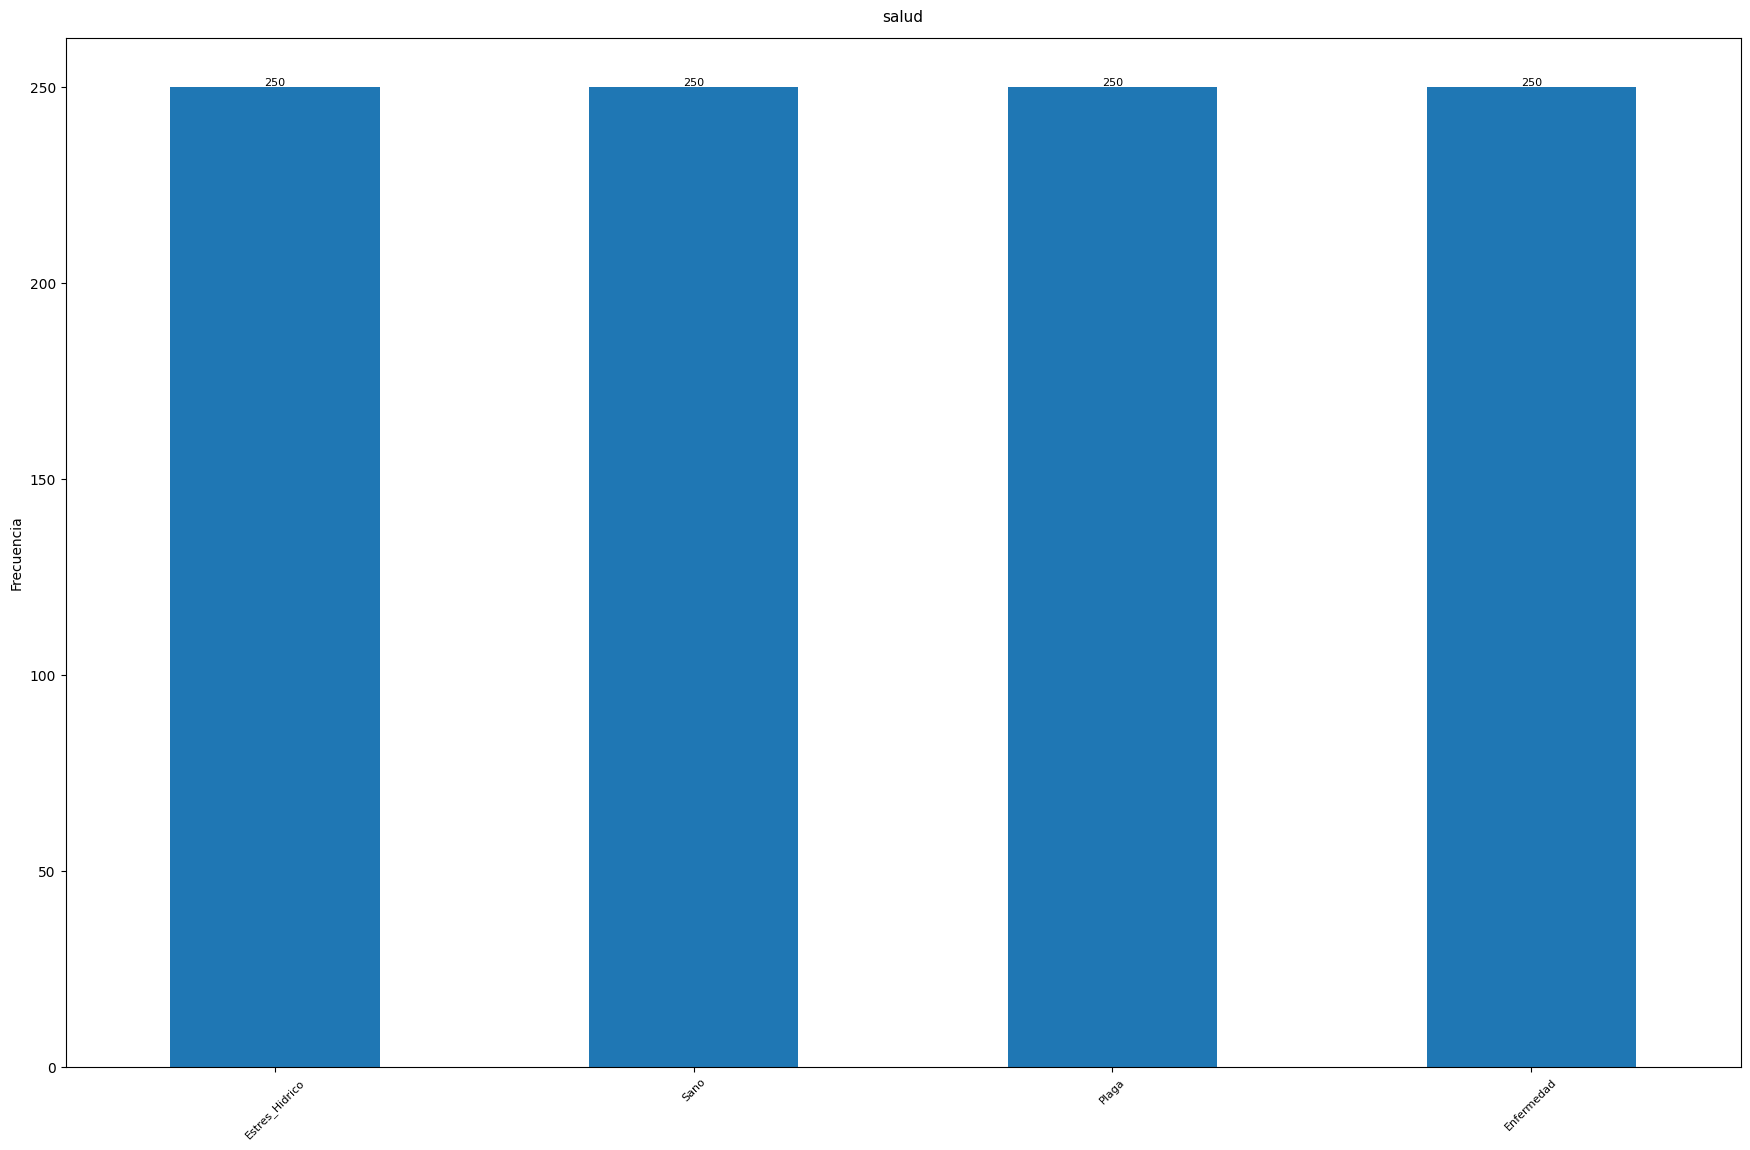

In [13]:
f_frecuencias_clases(datos)

# Desarrollo


# Interpretación del caso de estudio